---
title: "From Bloch States to Wannier Functions"
subtitle: "Gauge, Localization, and Operator Reconstruction"
---

# From Bloch States to Wannier Functions

## Purpose

This exploratory notebook constructs Wannier functions directly from Bloch eigenstates of a finite periodic tight-binding model using finite-dimensional linear algebra and a discrete Fourier transform.

It distinguishes:

1. the physical Hamiltonian operator;
2. its real-space matrix representation;
3. its decomposition into Bloch fibers;
4. the retained band subspace;
5. the gauge-dependent Bloch frame;
6. the corresponding Wannier basis; and
7. the restricted Hamiltonian in Wannier coordinates.

The notebook initially uses neither density-functional theory nor Wannier90. It is exploratory: it is not a canonical or supported PhysKit artifact, and its final pristine--dopant discussion is motivation rather than a completed alignment construction.

## Learning objectives

After completing this notebook, we should be able to construct a periodic tight-binding Hamiltonian, block-diagonalize it with the discrete Bloch transform, distinguish eigenvectors from projectors, apply momentum-dependent phases, construct Wannier functions, compare localization, reconstruct retained-band matrix elements, and explain why comparisons between independently constructed retained spaces require an explicit alignment.


# 1. Finite periodic state space

A one-dimensional periodic lattice contains $N$ unit cells and two orbitals, $A$ and $B$, per cell:

$$
\mathcal H_{\mathrm{real}}=\mathbb C^N\otimes\mathbb C^2,
\qquad \dim\mathcal H_{\mathrm{real}}=2N.
$$

The orthonormal basis is $\{|R,A\rangle,|R,B\rangle\}_{R=0}^{N-1}$, with periodic boundary conditions.


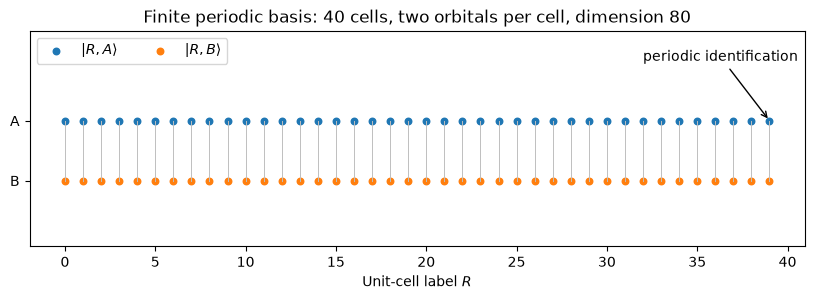

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.testing import assert_allclose

N = 40
a = 1.0
t1 = 1.0
t2 = 1.5
delta = 0.2

dimension = 2 * N
R_values = np.arange(N)

# Deterministic diagram of the finite two-orbital state-space layout.
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.scatter(R_values, np.full(N, 0.25), s=22, label=r"$|R,A\rangle$")
ax.scatter(R_values, np.full(N, -0.25), s=22, label=r"$|R,B\rangle$")
for R in range(N):
    ax.plot([R, R], [-0.25, 0.25], color="0.75", linewidth=0.7)
ax.annotate(
    "periodic identification",
    xy=(N - 1, 0.25),
    xytext=(N - 8, 0.75),
    arrowprops={"arrowstyle": "->"},
)
ax.set_yticks([-0.25, 0.25], ["B", "A"])
ax.set_xlabel("Unit-cell label $R$")
ax.set_title(f"Finite periodic basis: {N} cells, two orbitals per cell, dimension {dimension}")
ax.legend(loc="upper left", ncol=2)
ax.set_ylim(-0.8, 1.0)
plt.show()


### Interpretation

The diagram makes the finite representation visible: each cell contributes two basis vectors, while the annotation recalls that the first and last labels are periodically identified. The dimension and labels shown in the figure come directly from the executed parameter values. This picture is a schematic of basis organization, not a claim about orbital geometry or material structure.


# 2. Real-space Hamiltonian

We use an SSH-like Hamiltonian with intracell hopping $t_1$, intercell hopping $t_2$, and opposite onsite energies $\pm\Delta$:

$$
\hat H = \sum_R \Delta(|R,A\rangle\langle R,A|-|R,B\rangle\langle R,B|)
+\sum_R[t_1|R,A\rangle\langle R,B|+t_2|R+1,A\rangle\langle R,B|+\mathrm{h.c.}].
$$


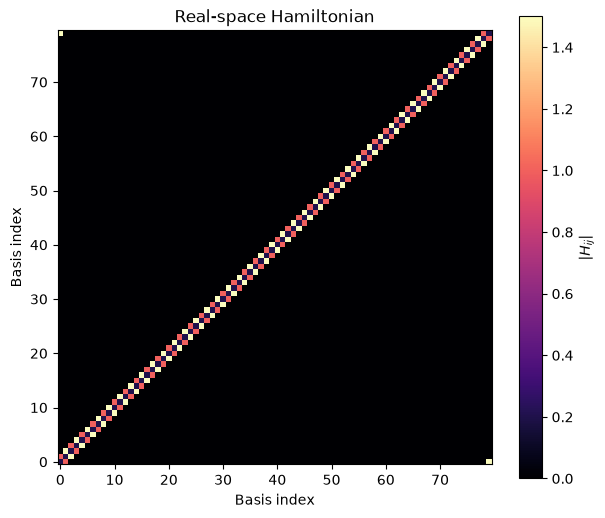

In [2]:
def basis_index(cell: int, orbital: int) -> int:
    return 2 * cell + orbital


H_real = np.zeros((dimension, dimension), dtype=complex)

for R in range(N):
    A_R = basis_index(R, 0)
    B_R = basis_index(R, 1)
    A_next = basis_index((R + 1) % N, 0)

    H_real[A_R, A_R] = delta
    H_real[B_R, B_R] = -delta
    H_real[A_R, B_R] += t1
    H_real[B_R, A_R] += t1
    H_real[A_next, B_R] += t2
    H_real[B_R, A_next] += t2

assert_allclose(H_real, H_real.conj().T, atol=1.0e-12)

plt.figure(figsize=(7, 6))
plt.imshow(np.abs(H_real), origin="lower", cmap="magma")
plt.colorbar(label=r"$|H_{ij}|$")
plt.xlabel("Basis index")
plt.ylabel("Basis index")
plt.title("Real-space Hamiltonian")
plt.show()


### Interpretation

The plotted matrix magnitude exposes onsite terms and the sparse intracell/intercell coupling pattern. Hermiticity is enforced by the executable assertion rather than inferred from visual symmetry. The image describes this finite model only; it does not validate the SSH-like Hamiltonian as a model of a particular material.


# 3. Translation symmetry and Bloch fibers

The allowed momenta and discrete Fourier matrix are

$$
k_j=\frac{2\pi j}{Na},\qquad
F_{kR}=\frac{1}{\sqrt N}e^{-ikRa}.
$$

The full transform is $\mathcal F=F\otimes I_2$ and
$H_k^{\mathrm{full}}=\mathcal F H_{\mathrm{real}}\mathcal F^\dagger$.


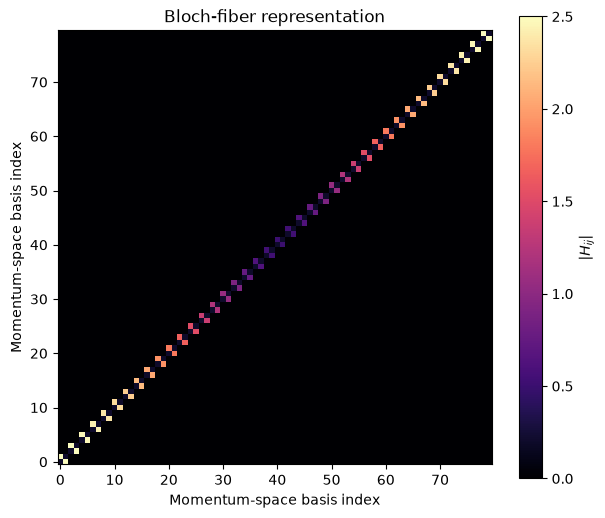

In [3]:
k_values = 2.0 * np.pi * np.arange(N) / (N * a)
F = np.exp(-1j * np.outer(k_values, R_values * a)) / np.sqrt(N)

assert_allclose(F.conj().T @ F, np.eye(N), atol=1.0e-12)

F_full = np.kron(F, np.eye(2))
assert_allclose(F_full.conj().T @ F_full, np.eye(2 * N), atol=1.0e-12)

H_k_full = F_full @ H_real @ F_full.conj().T

plt.figure(figsize=(7, 6))
plt.imshow(np.abs(H_k_full), origin="lower", cmap="magma")
plt.colorbar(label=r"$|H_{ij}|$")
plt.xlabel("Momentum-space basis index")
plt.ylabel("Momentum-space basis index")
plt.title("Bloch-fiber representation")
plt.show()


### Interpretation

The transformed matrix appears as a sequence of $2\times2$ momentum blocks. The following executable residual checks determine whether the apparent block structure agrees with the analytic fibers. Visual block diagonality is useful for orientation but is not, by itself, a numerical tolerance test.


# 4. Analytic Bloch Hamiltonian

For these conventions,

$$
H(k)=\begin{pmatrix}
\Delta&t_1+t_2e^{-ika}\\
t_1+t_2e^{ika}&-\Delta
\end{pmatrix}.
$$


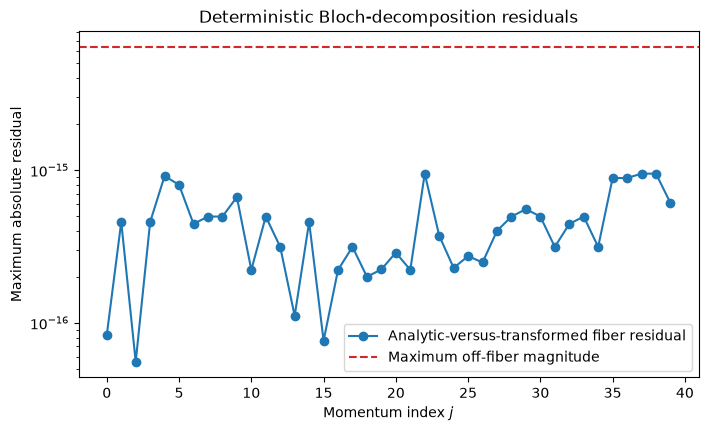

In [4]:
def bloch_hamiltonian(k: float) -> np.ndarray:
    off_diagonal = t1 + t2 * np.exp(-1j * k * a)
    return np.array(
        [[delta, off_diagonal], [np.conjugate(off_diagonal), -delta]],
        dtype=complex,
    )


for j, k in enumerate(k_values):
    block = H_k_full[2 * j : 2 * j + 2, 2 * j : 2 * j + 2]
    assert_allclose(block, bloch_hamiltonian(k), atol=1.0e-12)

# Confirm that all off-fiber blocks vanish.
block_mask = np.zeros_like(H_k_full, dtype=bool)
for j in range(N):
    block_mask[2 * j : 2 * j + 2, 2 * j : 2 * j + 2] = True
assert np.max(np.abs(H_k_full[~block_mask])) < 1.0e-12

fiber_residuals = np.array([
    np.max(np.abs(
        H_k_full[2 * j : 2 * j + 2, 2 * j : 2 * j + 2]
        - bloch_hamiltonian(k)
    ))
    for j, k in enumerate(k_values)
])
off_fiber_residual = np.max(np.abs(H_k_full[~block_mask]))
plot_floor = np.finfo(float).tiny

plt.figure(figsize=(8, 4.5))
plt.semilogy(
    np.arange(N),
    np.maximum(fiber_residuals, plot_floor),
    "o-",
    label="Analytic-versus-transformed fiber residual",
)
plt.axhline(
    max(off_fiber_residual, plot_floor),
    color="tab:red",
    linestyle="--",
    label="Maximum off-fiber magnitude",
)
plt.xlabel("Momentum index $j$")
plt.ylabel("Maximum absolute residual")
plt.title("Deterministic Bloch-decomposition residuals")
plt.legend()
plt.show()


### Interpretation

The residual diagram displays the quantities tested in code for every sampled momentum and for the off-fiber entries. Values near floating-point precision support the internal consistency of the chosen Fourier and hopping conventions. This is software/numerical consistency evidence for the constructed finite matrices, not physical validation.


# 5. Bloch eigenstates and band projectors

At each momentum, solve $H(k)|u_{nk}\rangle=E_n(k)|u_{nk}\rangle$. We retain the lower band. The name `u_lower` denotes the lower-band cell-periodic eigenvector; it does **not** mean a state at momentum $-k$.

The rank-one projector $P(k)=|u_{\mathrm{lower},k}\rangle\langle u_{\mathrm{lower},k}|$ is independent of the phase chosen for its eigenvector.


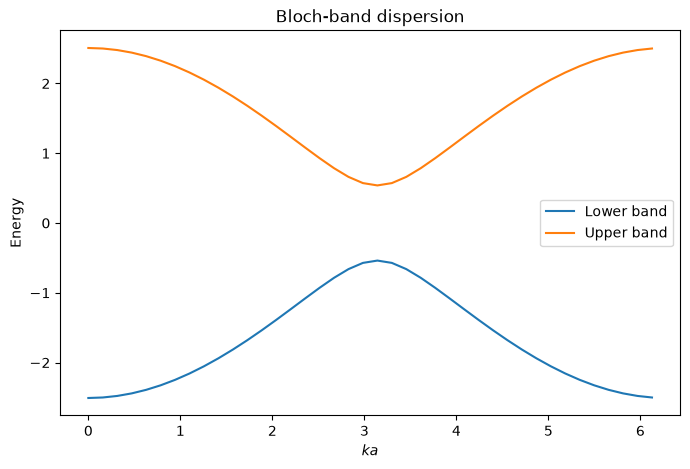

In [5]:
energies = np.zeros((N, 2))
eigenvectors = np.zeros((N, 2, 2), dtype=complex)

for j, k in enumerate(k_values):
    values, vectors = np.linalg.eigh(bloch_hamiltonian(k))
    energies[j] = values
    eigenvectors[j] = vectors

u_lower = eigenvectors[:, :, 0]
projectors = np.array([np.outer(u, np.conjugate(u)) for u in u_lower])

for j, P in enumerate(projectors):
    assert_allclose(P, P.conj().T, atol=1.0e-12)
    assert_allclose(P @ P, P, atol=1.0e-12)
    assert_allclose(bloch_hamiltonian(k_values[j]) @ u_lower[j], energies[j, 0] * u_lower[j], atol=1.0e-12)

plt.figure(figsize=(8, 5))
plt.plot(k_values * a, energies[:, 0], label="Lower band")
plt.plot(k_values * a, energies[:, 1], label="Upper band")
plt.xlabel(r"$ka$")
plt.ylabel("Energy")
plt.title("Bloch-band dispersion")
plt.legend()
plt.show()


### Interpretation

The graph shows two separated finite-lattice energy bands for the selected parameters. Eigenpair and projector identities are checked by code. Calling them “lower” and “upper” describes eigenvalue ordering; no occupancy, Fermi level, or material interpretation is implied.


# 6. Gauge freedom

For one isolated band, $|u_k\rangle\mapsto e^{i\phi(k)}|u_k\rangle$ changes the frame but leaves $P(k)$ unchanged.


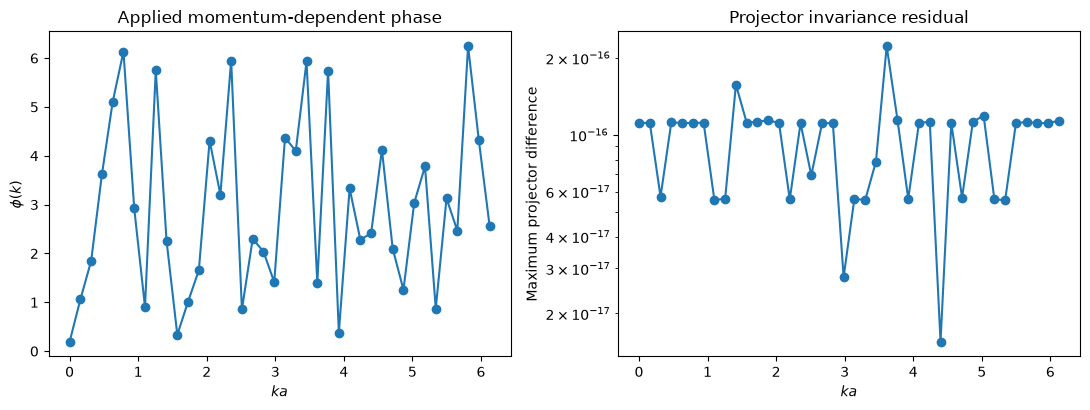

In [6]:
rng = np.random.default_rng(seed=1729)
random_phases = rng.uniform(0.0, 2.0 * np.pi, size=N)
u_random = np.exp(1j * random_phases)[:, None] * u_lower
projectors_random = np.array([np.outer(u, np.conjugate(u)) for u in u_random])

assert_allclose(projectors_random, projectors, atol=1.0e-12)

projector_gauge_errors = np.max(
    np.abs(projectors_random - projectors),
    axis=(1, 2),
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(k_values * a, random_phases, "o-")
axes[0].set_xlabel(r"$ka$")
axes[0].set_ylabel(r"$\phi(k)$")
axes[0].set_title("Applied momentum-dependent phase")
axes[1].semilogy(
    k_values * a,
    np.maximum(projector_gauge_errors, np.finfo(float).tiny),
    "o-",
)
axes[1].set_xlabel(r"$ka$")
axes[1].set_ylabel("Maximum projector difference")
axes[1].set_title("Projector invariance residual")
fig.tight_layout()
plt.show()


### Interpretation

The left panel shows the deliberately irregular phase field, while the right panel shows the corresponding projector residual. The executable equality check establishes invariance at the stated tolerance. The particular phase pattern is reproducible because the random-number seed is fixed; another seed would alter the left panel without changing the mathematical invariance.


# 7. Parallel-transport gauge

We sequentially adjust phases so neighboring overlaps are real and positive. This open-chain construction smooths the sampled frame but does **not** enforce periodic closure between the last and first momentum. The resulting closure phase is related to the discrete Berry phase and must be treated explicitly in a formal Wannier construction.


Parallel-transport closure phase: -2.50377570 rad


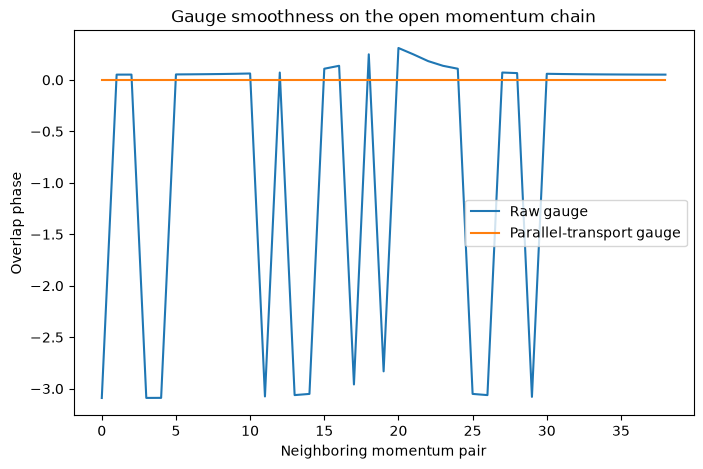

In [7]:
def parallel_transport_gauge(states: np.ndarray) -> np.ndarray:
    transported = states.copy()
    for j in range(1, len(transported)):
        overlap = np.vdot(transported[j - 1], transported[j])
        if np.abs(overlap) < 1.0e-14:
            raise ValueError("Adjacent Bloch states have nearly zero overlap.")
        transported[j] *= np.exp(-1j * np.angle(overlap))
    return transported


u_smooth = parallel_transport_gauge(u_lower)
raw_overlaps = np.array([np.vdot(u_lower[j], u_lower[j + 1]) for j in range(N - 1)])
smooth_overlaps = np.array([np.vdot(u_smooth[j], u_smooth[j + 1]) for j in range(N - 1)])

assert np.max(np.abs(np.angle(smooth_overlaps))) < 1.0e-12

closure_overlap = np.vdot(u_smooth[-1], u_smooth[0])
print(f"Parallel-transport closure phase: {np.angle(closure_overlap):.8f} rad")

plt.figure(figsize=(8, 5))
plt.plot(np.angle(raw_overlaps), label="Raw gauge")
plt.plot(np.angle(smooth_overlaps), label="Parallel-transport gauge")
plt.xlabel("Neighboring momentum pair")
plt.ylabel("Overlap phase")
plt.title("Gauge smoothness on the open momentum chain")
plt.legend()
plt.show()


### Interpretation

The neighboring-overlap phases are flattened along the open momentum chain by the sequential transport rule. The printed closure phase shows that local smoothing does not automatically enforce periodic closure. Its physical interpretation is intentionally deferred until a periodic gauge and Berry-phase convention are specified.


# 8. Construction of Wannier functions

With $|\psi_k\rangle=|k\rangle\otimes|u_k\rangle$, define

$$
|w_{R_0}\rangle=\frac{1}{\sqrt N}\sum_k e^{-ikR_0a}|\psi_k\rangle,
$$

so that

$$
\langle R,\alpha|w_{R_0}\rangle=\frac1N\sum_k e^{ik(R-R_0)a}u_\alpha(k).
$$


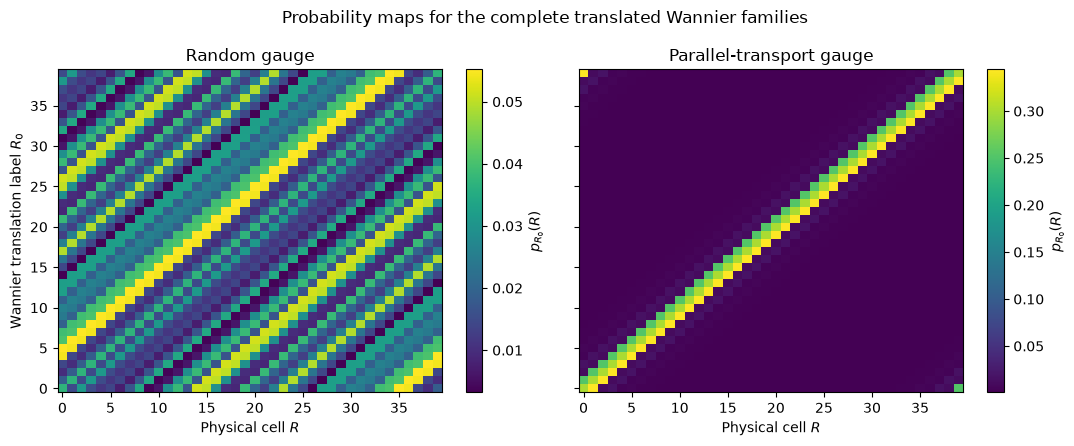

In [8]:
def construct_wannier_functions(bloch_states: np.ndarray) -> np.ndarray:
    wannier = np.zeros((N, N, 2), dtype=complex)
    for R0 in range(N):
        for R in range(N):
            phase = np.exp(1j * k_values * (R - R0) * a)
            wannier[R0, R] = np.sum(phase[:, None] * bloch_states, axis=0) / N
    return wannier


w_random = construct_wannier_functions(u_random)
w_smooth = construct_wannier_functions(u_smooth)

probability_map_random = np.sum(np.abs(w_random) ** 2, axis=2)
probability_map_smooth = np.sum(np.abs(w_smooth) ** 2, axis=2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, probability_map, title in [
    (axes[0], probability_map_random, "Random gauge"),
    (axes[1], probability_map_smooth, "Parallel-transport gauge"),
]:
    image = ax.imshow(probability_map, origin="lower", aspect="auto", cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("Physical cell $R$")
    fig.colorbar(image, ax=ax, label=r"$p_{R_0}(R)$")
axes[0].set_ylabel("Wannier translation label $R_0$")
fig.suptitle("Probability maps for the complete translated Wannier families")
fig.tight_layout()
plt.show()


### Interpretation

Each heat map displays the entire translated family rather than one selected state. The diagonal translation pattern is expected from the Fourier construction, while the different transverse widths reflect the chosen phase frames. These images compare two frames for the same projector; they do not establish maximal localization.


# 9. Real-space probability distribution

For a Wannier state centered by its translation label $R_0$, define
$p_{R_0}(R)=\sum_\alpha|\langle R,\alpha|w_{R_0}\rangle|^2$.


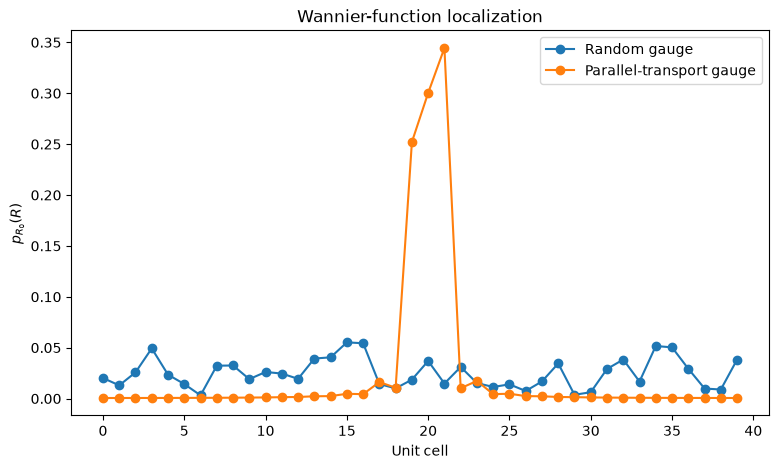

In [9]:
def cell_probability(wannier_state: np.ndarray) -> np.ndarray:
    return np.sum(np.abs(wannier_state) ** 2, axis=1)


R0 = N // 2
probability_random = cell_probability(w_random[R0])
probability_smooth = cell_probability(w_smooth[R0])

assert_allclose(np.sum(probability_random), 1.0, atol=1.0e-12)
assert_allclose(np.sum(probability_smooth), 1.0, atol=1.0e-12)

plt.figure(figsize=(9, 5))
plt.plot(R_values, probability_random, "o-", label="Random gauge")
plt.plot(R_values, probability_smooth, "o-", label="Parallel-transport gauge")
plt.xlabel("Unit cell")
plt.ylabel(r"$p_{R_0}(R)$")
plt.title("Wannier-function localization")
plt.legend()
plt.show()


### Interpretation

The selected-center plot gives a one-dimensional slice through the preceding family maps. Normalization is checked in code. The smoother-looking profile is an observation for this model, grid, seed, and open-chain transport prescription—not a universal claim that every locally smooth gauge is maximally localized.


# 10. Orthonormality, translation covariance, and projectors

Flatten the $N$ translated Wannier functions into columns of a $2N\times N$ matrix $W$. They should be orthonormal and span the same retained subspace as the Bloch states.


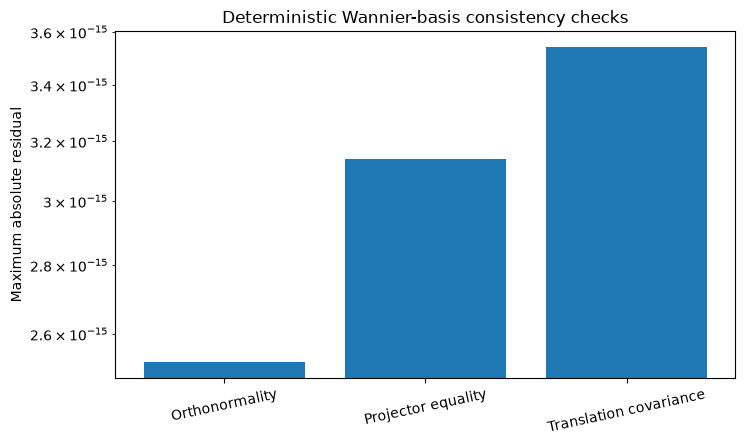

In [10]:
W_smooth = np.array([w_smooth[R].reshape(-1) for R in range(N)]).T
assert_allclose(W_smooth.conj().T @ W_smooth, np.eye(N), atol=1.0e-12)

# Translating a Wannier state by one cell advances its center label by one.
for center in range(N):
    assert_allclose(
        np.roll(W_smooth[:, center], 2),
        W_smooth[:, (center + 1) % N],
        atol=1.0e-12,
    )

P_wannier = W_smooth @ W_smooth.conj().T
bloch_full = np.zeros((2 * N, N), dtype=complex)
for j, k in enumerate(k_values):
    cell_phase = np.exp(1j * k * R_values * a) / np.sqrt(N)
    bloch_full[:, j] = np.kron(cell_phase, u_smooth[j])

assert_allclose(bloch_full.conj().T @ bloch_full, np.eye(N), atol=1.0e-12)
P_bloch = bloch_full @ bloch_full.conj().T
assert_allclose(P_wannier, P_bloch, atol=1.0e-12)

gram_residual = np.max(np.abs(W_smooth.conj().T @ W_smooth - np.eye(N)))
projector_residual = np.max(np.abs(P_wannier - P_bloch))
translation_residual = max(
    np.max(np.abs(
        np.roll(W_smooth[:, center], 2)
        - W_smooth[:, (center + 1) % N]
    ))
    for center in range(N)
)

labels = ["Orthonormality", "Projector equality", "Translation covariance"]
residuals = [gram_residual, projector_residual, translation_residual]
plt.figure(figsize=(8, 4.5))
plt.bar(labels, np.maximum(residuals, np.finfo(float).tiny))
plt.yscale("log")
plt.ylabel("Maximum absolute residual")
plt.title("Deterministic Wannier-basis consistency checks")
plt.xticks(rotation=12)
plt.show()


### Interpretation

The three plotted residuals summarize orthonormality, retained-projector equality, and translation covariance, all of which are enforced by executable assertions. Their small values show consistency among the finite representations. They do not address completeness outside the retained band or the adequacy of the physical model.


# 11. Exploratory localization measure

On the finite ring, use minimum-image displacements relative to the translation label $R_0$ and compute a quadratic spread. This is an exploratory diagnostic, not the full periodic-position or Marzari--Vanderbilt spread functional. In particular, a nonzero Wannier-center shift and the momentum-boundary closure require more careful treatment.


Random-gauge exploratory spread: 134.38173058
Parallel-transport exploratory spread: 5.38757997


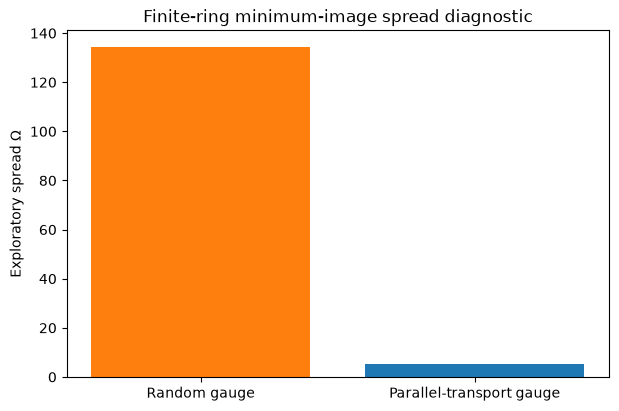

In [11]:
def periodic_displacements(center: int) -> np.ndarray:
    displacement = R_values - center
    return (displacement + N // 2) % N - N // 2


def quadratic_spread(probability: np.ndarray, center: int) -> float:
    x = a * periodic_displacements(center)
    mean_x = np.sum(probability * x)
    mean_x2 = np.sum(probability * x**2)
    return float(mean_x2 - mean_x**2)


spread_random = quadratic_spread(probability_random, R0)
spread_smooth = quadratic_spread(probability_smooth, R0)

print(f"Random-gauge exploratory spread: {spread_random:.8f}")
print(f"Parallel-transport exploratory spread: {spread_smooth:.8f}")

plt.figure(figsize=(7, 4.5))
plt.bar(
    ["Random gauge", "Parallel-transport gauge"],
    [spread_random, spread_smooth],
    color=["tab:orange", "tab:blue"],
)
plt.ylabel(r"Exploratory spread $\Omega$")
plt.title("Finite-ring minimum-image spread diagnostic")
plt.show()


### Interpretation

For this seeded example, the minimum-image diagnostic is smaller in the parallel-transport frame. The graph reports the executed finite-ring formula only. Because that formula is centered on the translation label and does not implement periodic-position or Marzari--Vanderbilt theory, it should not be read as a gauge-optimal localization result.


# 12. Hamiltonian in Wannier coordinates

The retained Hamiltonian has matrix elements
$H_{RR'}=\langle w_R|\hat H|w_{R'}\rangle$.


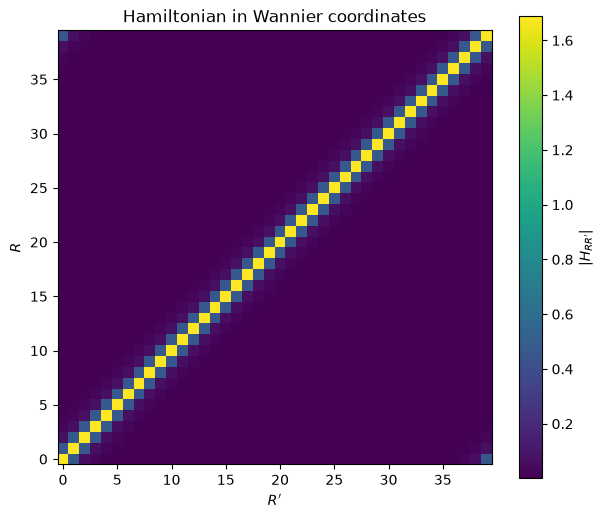

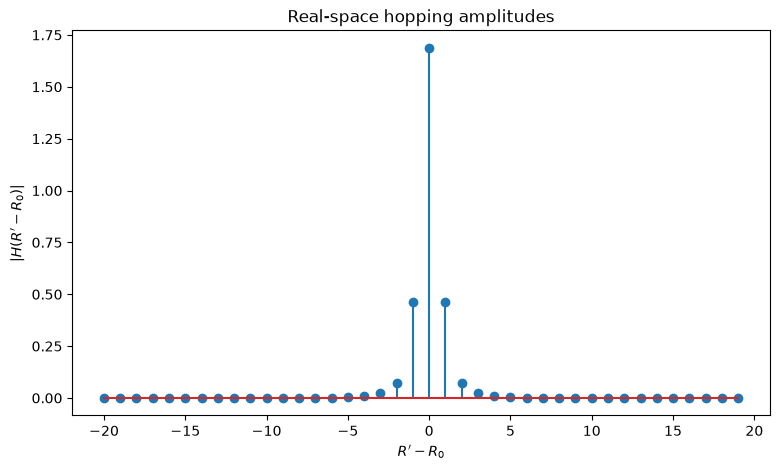

In [12]:
H_wannier = W_smooth.conj().T @ H_real @ W_smooth
assert_allclose(H_wannier, H_wannier.conj().T, atol=1.0e-12)

# Translation symmetry makes the matrix circulant.
for R in range(N):
    assert_allclose(H_wannier[R], np.roll(H_wannier[0], R), atol=1.0e-12)

plt.figure(figsize=(7, 6))
plt.imshow(np.abs(H_wannier), origin="lower", cmap="viridis")
plt.colorbar(label=r"$|H_{RR'}|$")
plt.xlabel(r"$R'$" )
plt.ylabel(r"$R$")
plt.title("Hamiltonian in Wannier coordinates")
plt.show()

hopping_from_origin = H_wannier[R0]
plt.figure(figsize=(9, 5))
plt.stem(periodic_displacements(R0), np.abs(hopping_from_origin))
plt.xlabel(r"$R'-R_0$")
plt.ylabel(r"$|H(R'-R_0)|$")
plt.title("Real-space hopping amplitudes")
plt.show()


### Interpretation

The matrix image and origin-row stem plot show the restricted operator in translated Wannier coordinates. Circulant structure and Hermiticity are checked in code. The visible decay pattern belongs to the retained dispersion of this finite model and is not evidence for a universal hopping range.


# 13. Reconstruction of the retained band

The retained dispersion is reconstructed as

$$
E(k)=\sum_{\Delta R}e^{ik\Delta R a}H(\Delta R).
$$


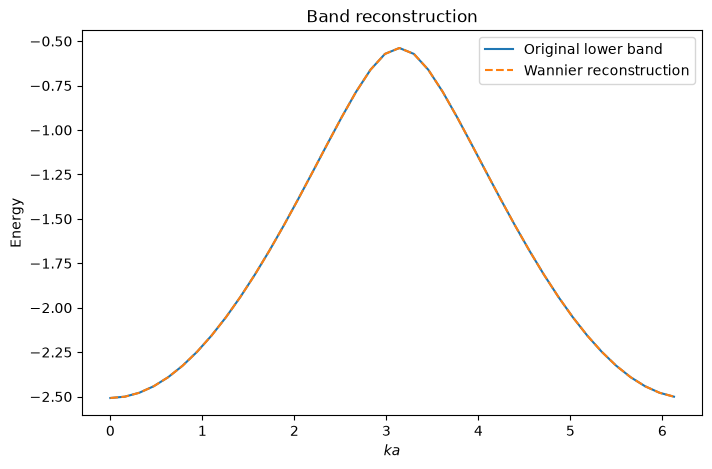

In [13]:
displacements = periodic_displacements(R0)
reconstructed_energy = np.array([
    np.sum(np.exp(1j * k * displacements * a) * hopping_from_origin)
    for k in k_values
])

assert np.max(np.abs(reconstructed_energy.imag)) < 1.0e-12
assert_allclose(reconstructed_energy.real, energies[:, 0], atol=1.0e-10)

plt.figure(figsize=(8, 5))
plt.plot(k_values * a, energies[:, 0], label="Original lower band")
plt.plot(k_values * a, reconstructed_energy.real, "--", label="Wannier reconstruction")
plt.xlabel(r"$ka$")
plt.ylabel("Energy")
plt.title("Band reconstruction")
plt.legend()
plt.show()


### Interpretation

The overlaid curves make the Fourier reconstruction visually inspectable, while the executable assertion compares every sampled momentum numerically. Agreement establishes equivalence of these two finite representations of the retained band under the stated conventions; it does not validate an external band-structure calculation.


# 14. What the single-band gauge experiment does—and does not—show

The individual Wannier functions depend on the momentum-dependent $U(1)$ phase. However, for one isolated band the phase cancels from

$$
H_{RR'}=\frac1N\sum_k e^{ik(R-R')a}E(k).
$$

Therefore the Wannier Hamiltonian is elementwise gauge invariant in this specific experiment. The change-of-basis matrix is nontrivial, but it commutes with the restricted Hamiltonian. A nontrivial matrix-coordinate comparison requires, for example, a composite retained subspace with momentum-dependent $U(M)$ mixing. That redesign is intentionally deferred from this exploratory notebook.


Single-band Wannier-Hamiltonian difference: 6.118617743693812e-14
Wannier-basis change from identity: 8.977726964642212


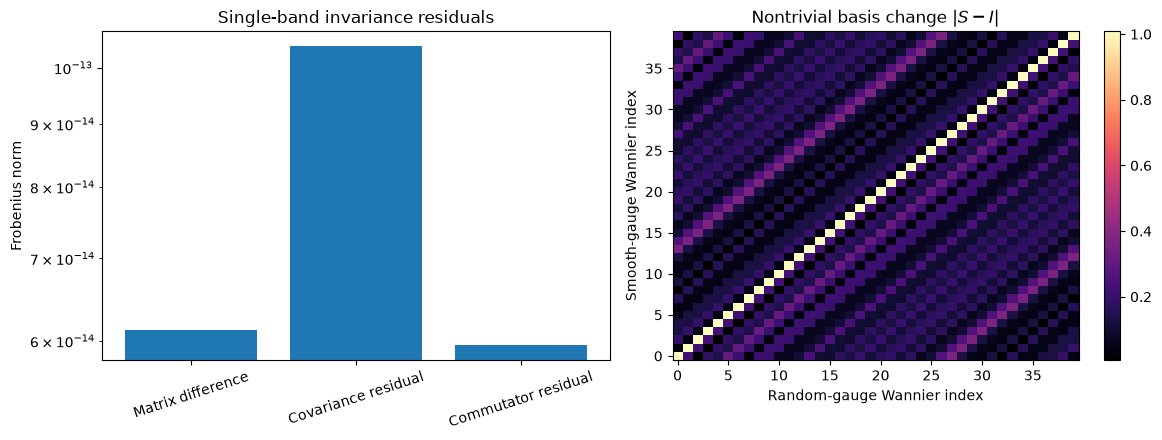

In [14]:
W_random = np.array([w_random[R].reshape(-1) for R in range(N)]).T
H_wannier_random = W_random.conj().T @ H_real @ W_random
S = W_smooth.conj().T @ W_random

assert_allclose(S.conj().T @ S, np.eye(N), atol=1.0e-12)
assert_allclose(H_wannier_random, H_wannier, atol=1.0e-10)
assert_allclose(H_wannier_random, S.conj().T @ H_wannier @ S, atol=1.0e-10)
assert_allclose(H_wannier @ S, S @ H_wannier, atol=1.0e-10)

print("Single-band Wannier-Hamiltonian difference:", np.linalg.norm(H_wannier_random - H_wannier))
print("Wannier-basis change from identity:", np.linalg.norm(S - np.eye(N)))

invariance_metrics = {
    "Matrix difference": np.linalg.norm(H_wannier_random - H_wannier),
    "Covariance residual": np.linalg.norm(
        H_wannier_random - S.conj().T @ H_wannier @ S
    ),
    "Commutator residual": np.linalg.norm(H_wannier @ S - S @ H_wannier),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(
    list(invariance_metrics),
    np.maximum(list(invariance_metrics.values()), np.finfo(float).tiny),
)
axes[0].set_yscale("log")
axes[0].set_ylabel("Frobenius norm")
axes[0].set_title("Single-band invariance residuals")
axes[0].tick_params(axis="x", rotation=18)
image = axes[1].imshow(np.abs(S - np.eye(N)), origin="lower", cmap="magma", aspect="auto")
axes[1].set_xlabel("Random-gauge Wannier index")
axes[1].set_ylabel("Smooth-gauge Wannier index")
axes[1].set_title(r"Nontrivial basis change $|S-I|$")
fig.colorbar(image, ax=axes[1])
fig.tight_layout()
plt.show()


### Interpretation

The residual panel shows that the restricted one-band Hamiltonian is unchanged to numerical precision even though the $|S-I|$ image shows a nontrivial Wannier-basis transformation. This special result follows from phase cancellation for a single isolated band. A genuinely coordinate-dependent Hamiltonian example requires an authorized composite-band construction and is not inferred from this diagram.


# 15. Motivation for pristine--dopant alignment

Suppose two periodic calculations produce restricted operators $\hat H_b^{(P)}$ and $\hat H_d^{(P)}$. If their retained spaces and Wannier frames are constructed independently, their numerical matrices are not automatically expressed in identified coordinates. A meaningful comparison requires an explicit unitary identification

$$
\hat U_d:\mathcal H_b^{(P)}\longrightarrow\mathcal H_d^{(P)},
$$

leading to

$$
\Delta\hat H_d^{(P)}=\hat U_d^\dagger\hat H_d^{(P)}\hat U_d-\hat H_b^{(P)}.
$$

The present one-band phase experiment does not construct two different retained spaces and therefore does not validate a pristine--dopant subtraction procedure. It only exposes frame dependence of individual Wannier functions and the special gauge invariance of the one-band retained Hamiltonian matrix.


# 16. Summary and deferred extensions

This notebook explicitly constructed

$$
\mathcal H_{\mathrm{real}}
\xrightarrow{\mathcal F}
\bigoplus_k\mathcal H(k)
\xrightarrow{P(k)}
\bigoplus_k\mathcal H^{(P)}(k)
\xrightarrow{\text{gauge}}
\{|u_k\rangle\}
\xrightarrow{\text{Fourier transform}}
\{|w_R\rangle\}.
$$

The retained projector is gauge invariant, while Bloch and Wannier vectors are gauge dependent. Gauge smoothness affects the real-space shape of individual Wannier functions. For a single isolated band, the retained Wannier Hamiltonian is nevertheless fixed by the dispersion and is elementwise invariant under $U(1)$ phases.

Deferred extensions include periodic-gauge closure and Zak phase, a robust periodic spread functional, composite-band $U(M)$ gauge transformations, subspace selection for entangled bands, Marzari--Vanderbilt localization, imported electronic-structure data, and comparison with Wannier90. Any formalization requires a separate capability contract and authorization.
